In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import the libraries as shown below

from tensorflow.keras.layers import Input,Lambda, Dense, Flatten,Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [ ]:


# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = '/content/drive/MyDrive/Maleria_Dataset/Train'
valid_path = '/content/drive/MyDrive/Maleria_Dataset/Test'


In [ ]:
# Import the Vgg 16 library as shown below and add preprocessing layer to the front of VGG
# Here we will be using imagenet weights

vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)




In [ ]:
# don't train existing weights
for layer in vgg.layers:
    layer.trainable = False

In [ ]:
  # useful for getting number of output classes
folders = glob('/content/drive/MyDrive/Maleria_Dataset/Train')




In [ ]:
!ls '/content/drive/MyDrive/Maleria_Dataset/Train'

Parasite  Uninfected


In [ ]:
folders

['/content/drive/MyDrive/Maleria_Dataset/Train']

In [ ]:
x = Flatten()(vgg.output)

In [ ]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.layers import MaxPooling2D

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

vgg_model = Sequential()
pretrained_model = tf.keras.applications.VGG16(include_top=False,
                                                 input_shape=(224,224,3),
                                                 pooling='max',
                                                 weights='imagenet')
for layer in pretrained_model.layers:
        layer.trainable=False
vgg_model.add(pretrained_model)
vgg_model.add(Flatten())
vgg_model.add(Dense(512, activation='relu'))
vgg_model.add(Dense(2, activation='softmax'))

In [ ]:
# tell the model what cost and optimization method to use
vgg_model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)


In [ ]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

#test_datagen = ImageDataGenerator(rescale = 1./255)

test_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

In [ ]:

train_datagen

In [ ]:
test_datagen

In [ ]:
# Make sure you provide the same target size as initialied for the image size
training_set = train_datagen.flow_from_directory('/content/drive/MyDrive/Maleria_Dataset/Train',target_size = (224, 224),batch_size = 32,class_mode = 'categorical')

Found 436 images belonging to 2 classes.


In [ ]:
training_set

In [ ]:
test_set = test_datagen.flow_from_directory('/content/drive/MyDrive/Maleria_Dataset/Test',target_size = (224, 224),batch_size = 32,class_mode = 'categorical')

Found 134 images belonging to 2 classes.


In [ ]:

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


r = vgg_model.fit(training_set,validation_data=test_set,epochs=5)


Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 393s 27s/step - accuracy: 0.5275 - loss: 1.1043 - val_accuracy: 0.6791 - val_loss: 0.6104
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 321s 23s/step - accuracy: 0.7248 - loss: 0.5442 - val_accuracy: 0.6940 - val_loss: 0.5498
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 313s 23s/step - accuracy: 0.8005 - loss: 0.4642 - val_accuracy: 0.7313 - val_loss: 0.5265
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 321s 24s/step - accuracy: 0.8326 - loss: 0.4156 - val_accuracy: 0.7388 - val_loss: 0.4693
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 315s 23s/step - accuracy: 0.8578 - loss: 0.3750 - val_accuracy: 0.7463 - val_loss: 0.5044


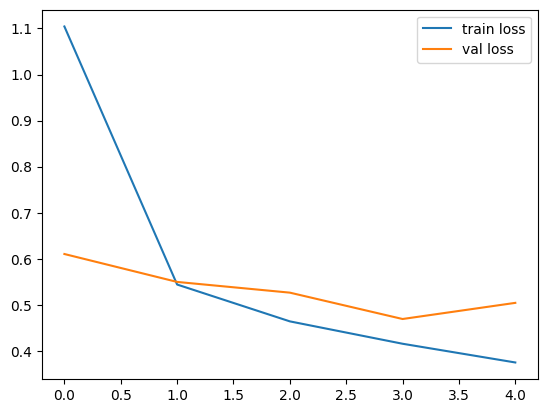

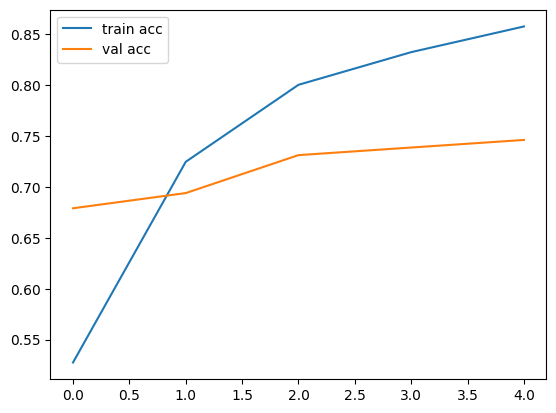

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [ ]:
# save it as a h5 file


from tensorflow.keras.models import load_model

model.save('vgg_model.h5')

In [ ]:

y_pred = vgg_model.predict(test_set)


5/5 ━━━━━━━━━━━━━━━━━━━━ 75s 14s/step


In [ ]:
y_pred

array([[0.9971152 , 0.00288478],
       [0.5202264 , 0.47977358],
       [0.48269442, 0.5173056 ],
       [0.30957395, 0.69042605],
       [0.5534234 , 0.4465766 ],
       [0.26825103, 0.7317489 ],
       [0.92439514, 0.07560477],
       [0.5997163 , 0.40028363],
       [0.34416485, 0.65583515],
       [0.69877803, 0.3012219 ],
       [0.47191256, 0.5280874 ],
       [0.8119593 , 0.18804066],
       [0.89943844, 0.10056152],
       [0.32392514, 0.676075  ],
       [0.64568543, 0.35431463],
       [0.54447347, 0.45552653],
       [0.980257  , 0.01974294],
       [0.28401965, 0.7159803 ],
       [0.40804663, 0.59195334],
       [0.5407277 , 0.4592723 ],
       [0.62800527, 0.37199476],
       [0.7329486 , 0.2670514 ],
       [0.8388021 , 0.16119793],
       [0.96150917, 0.03849088],
       [0.82271725, 0.17728268],
       [0.33172277, 0.66827726],
       [0.3419579 , 0.65804213],
       [0.152707  , 0.847293  ],
       [0.4652513 , 0.5347487 ],
       [0.35334805, 0.6466519 ],
       [0.

In [ ]:
import numpy as np

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [ ]:
model=load_model('vgg_model.h5')

In [ ]:
img=image.load_img('/content/drive/MyDrive/Maleria_Dataset/Train/Parasite/C133P94ThinF_IMG_20151004_155721_cell_112.png',target_size=(224,224))



In [ ]:
x=x/255

In [ ]:
x=image.img_to_array(img)
x

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)

In [ ]:
x.shape

(224, 224, 3)

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

img_data=preprocess_input(x)
img_data.shape

(224, 224, 3)

In [ ]:
vgg_model.predict(np.expand_dims(img_data, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step


array([[1., 0.]], dtype=float32)

In [ ]:
a=np.argmax(vgg_model.predict(np.expand_dims(img_data, axis=0)), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step


In [ ]:
if(a==1):
    print("Uninfected")
else:
    print("Infected")

Infected


Chest CT Scan

In [ ]:


# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = '/content/drive/MyDrive/ChestCTscan/Data/train'
valid_path = '/content/drive/MyDrive/ChestCTscan/Data/valid'
test_path = '/content/drive/MyDrive/ChestCTscan/Data/test'


In [ ]:
vgg_model = Sequential()
pretrained_model = tf.keras.applications.VGG16(include_top=False,
                                                 input_shape=IMAGE_SIZE + [3],
                                                 pooling='max',
                                                 weights='imagenet')
for layer in pretrained_model.layers:
        layer.trainable=False
vgg_model.add(pretrained_model)
vgg_model.add(Flatten())
vgg_model.add(Dense(512, activation='relu'))
vgg_model.add(Dense(4, activation='softmax')) # Updated to 4 classes for Chest CT scan dataset

# Model compilation
vgg_model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

# Image Data Generator setup
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

# Flow from directory using Chest CT Scan paths
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(test_path,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 613 images belonging to 4 classes.
Found 315 images belonging to 4 classes.


In [ ]:
# Train the vgg_model for Chest CT Scan dataset
chest_r = vgg_model.fit(training_set,
                        validation_data=test_set,
                        epochs=5)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 603s 30s/step - accuracy: 0.4111 - loss: 1.4120 - val_accuracy: 0.5524 - val_loss: 0.9877
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 517s 26s/step - accuracy: 0.5824 - loss: 0.9874 - val_accuracy: 0.5143 - val_loss: 0.9843
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 516s 26s/step - accuracy: 0.6395 - loss: 0.8174 - val_accuracy: 0.6635 - val_loss: 0.8177
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 522s 27s/step - accuracy: 0.7423 - loss: 0.6883 - val_accuracy: 0.6794 - val_loss: 0.7760
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 517s 26s/step - accuracy: 0.7210 - loss: 0.6324 - val_accuracy: 0.6762 - val_loss: 0.7593


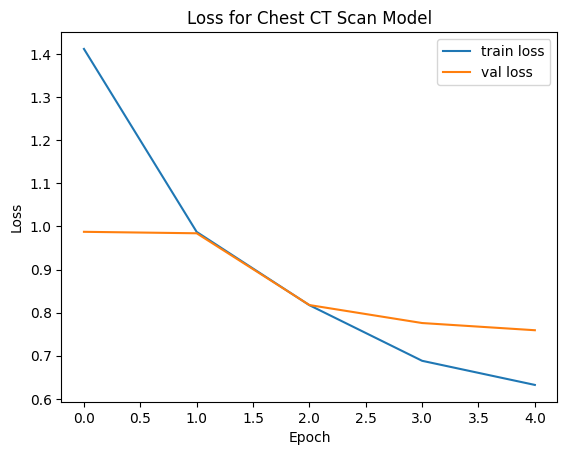

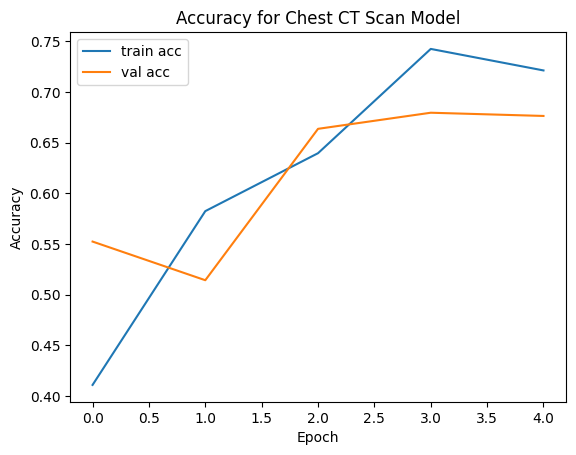

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# plot the loss for Chest CT Scan model
plt.plot(chest_r.history['loss'], label='train loss')
plt.plot(chest_r.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss for Chest CT Scan Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()
plt.savefig('ChestCT_LossVal_loss')

# plot the accuracy for Chest CT Scan model
plt.plot(chest_r.history['accuracy'], label='train acc')
plt.plot(chest_r.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy for Chest CT Scan Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()
plt.savefig('ChestCT_AccVal_acc')

In [ ]:
vgg_model.save('chest_ct_scan_vgg_model.h5')
print("Chest CT Scan model saved as 'chest_ct_scan_vgg_model.h5'")

Chest CT Scan model saved as 'chest_ct_scan_vgg_model.h5'


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
import os

# Get class names from the training set
class_names = list(training_set.class_indices.keys())
print(f"Class names for prediction: {class_names}")

# Dynamically find an image path in the 'normal' test directory
base_test_path = '/content/drive/MyDrive/ChestCTscan/Data/test/'
normal_dir = os.path.join(base_test_path, 'normal')
img_path = None

if os.path.exists(normal_dir):
    files_in_normal = [f for f in os.listdir(normal_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if files_in_normal:
        img_path = os.path.join(normal_dir, files_in_normal[0])
        print(f"Using dynamically found image: {img_path}")
    else:
        print(f"No image files found in {normal_dir}. Please ensure images exist in this directory.")
else:
    print(f"Directory {normal_dir} does not exist. Please check your dataset path.")

if img_path:
    img = image.load_img(img_path, target_size=(224, 224))

    x = image.img_to_array(img)
    img_data = preprocess_input(np.expand_dims(x, axis=0))

    # Make prediction
    prediction = vgg_model.predict(img_data)
    predicted_class_index = np.argmax(prediction, axis=1)[0]
    predicted_class_name = class_names[predicted_class_index]

    print(f"The image is predicted as: {predicted_class_name}")
    print(f"Prediction probabilities: {prediction}")
else:
    print("Could not proceed with prediction due to missing image path.")

Class names for prediction: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Using dynamically found image: /content/drive/MyDrive/ChestCTscan/Data/test/normal/10 - Copy (3).png


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
The image is predicted as: normal
Prediction probabilities: [[0. 0. 1. 0.]]


In [ ]:
This notebook demonstrates how to use transfer learning with a pre-trained VGG16 model for two distinct image classification tasks: Malaria detection and Chest CT scan classification.

Here's a breakdown of the code:

### 1. Initial Setup and Library Imports
*   **Mount Google Drive**: The first step is to connect Google Colab to your Google Drive (`drive.mount('/content/drive')`) to access the datasets stored there.
*   **Import Libraries**: Essential libraries from TensorFlow/Keras are imported. These include:
    *   `Input`, `Lambda`, `Dense`, `Flatten`, `Conv2D` from `tensorflow.keras.layers`: For building the neural network architecture.
    *   `Model` from `tensorflow.keras.models`: To create a functional API model.
    *   `VGG16` from `tensorflow.keras.applications.vgg16`: The pre-trained convolutional neural network that will be used for transfer learning.
    *   `image`, `ImageDataGenerator`, `load_img` from `tensorflow.keras.preprocessing`: For loading, preprocessing, and augmenting image data.
    *   `Sequential` from `tensorflow.keras.models`: Another way to build a neural network model (used later).
    *   `numpy`: For numerical operations.
    *   `glob`: To find file paths matching a pattern (used to determine class count).
    *   `matplotlib.pyplot`: For plotting training history.

### 2. Malaria Detection Model

#### Data Preparation:
*   **`IMAGE_SIZE = [224, 224]`**: Defines the target size for all input images, a common input size for VGG16.
*   **`train_path`, `valid_path`**: Specifies the paths to the training and testing datasets for Malaria detection on your Google Drive.

#### VGG16 Base Model Setup:
*   **`vgg = VGG16(...)`**: Initializes the VGG16 model.
    *   `input_shape=IMAGE_SIZE + [3]`: Sets the expected input shape (224x224 pixels, 3 color channels).
    *   `weights='imagenet'`: Loads the weights pre-trained on the ImageNet dataset.
    *   `include_top=False`: Crucially, this removes the original classification layers (the 'top') of VGG16, allowing you to add your own custom classification layers for Malaria detection.
*   **`for layer in vgg.layers: layer.trainable = False`**: This step 'freezes' the weights of the VGG16 base layers. This means these layers will not be updated during training, effectively using VGG16 as a fixed feature extractor.

#### Custom Classification Head:
*   **`folders = glob('/content/drive/MyDrive/Maleria_Dataset/Train/*')`**: This line (implied by the `!ls` and `len(folders)` usage) finds the subdirectories within the training path, which typically represent the different classes (e.g., 'Parasite', 'Uninfected'). `len(folders)` will give the number of output classes.
*   **`x = Flatten()(vgg.output)`**: Takes the output of the VGG16 convolutional base (which is a 3D feature map) and flattens it into a 1D vector. This is necessary to feed it into a fully connected (Dense) layer.
*   **`prediction = Dense(len(folders), activation='softmax')(x)`**: Adds a new fully connected layer on top of the flattened features.
    *   `len(folders)`: The number of neurons in this layer equals the number of output classes.
    *   `activation='softmax'`: This activation function is used for multi-class classification, outputting a probability distribution over the classes.
*   **`model = Model(inputs=vgg.input, outputs=prediction)`**: Creates the final Keras model by connecting the VGG16 input to the output of your new prediction layer.
*   **`model.summary()`**: Prints a detailed summary of the model's architecture, including the number of parameters.

#### Alternative Model Definition (Sequential API):
*   A separate `vgg_model` is defined using the `Sequential` API, which stacks layers linearly. This model also uses the `VGG16` pre-trained model with `include_top=False` and frozen layers. It then adds `Flatten` and two `Dense` layers: one with 512 units and 'relu' activation, and the final output layer with 2 units (for binary classification: Parasite/Uninfected) and 'softmax' activation.

#### Model Compilation and Training:
*   **`vgg_model.compile(...)`**: Configures the model for training:
    *   `loss='categorical_crossentropy'`: The loss function used for multi-class classification. It measures how well the model's predicted probabilities match the true labels.
    *   `optimizer='adam'`: An efficient optimization algorithm that adjusts the model's weights during training to minimize the loss.
    *   `metrics=['accuracy']`: The metric used to evaluate the model's performance during training and testing.
*   **`ImageDataGenerator` Setup**:
    *   `train_datagen`, `test_datagen`: These objects are used to preprocess images and perform data augmentation.
    *   `rescale=1./255`: Normalizes pixel values from the 0-255 range to 0-1, which helps neural networks learn more effectively.
    *   `shear_range`, `zoom_range`, `horizontal_flip`: These are data augmentation techniques that introduce variations to the training images (e.g., slight distortions, zooming, flipping) to prevent overfitting and improve generalization.
*   **`flow_from_directory(...)`**: These methods create data generators that read images directly from organized directories (where subfolders represent classes).
    *   `target_size=(224, 224)`: Resizes all images to the specified dimension.
    *   `batch_size=32`: Processes images in batches of 32.
    *   `class_mode='categorical'`: Specifies that the labels should be one-hot encoded (e.g., [1,0] for class A, [0,1] for class B).
*   **`r = vgg_model.fit(...)`**: Starts the training process.
    *   `training_set`: The data generator for training images.
    *   `validation_data=test_set`: The data generator for evaluating the model on unseen data after each epoch.
    *   `epochs=5`: The number of times the model will iterate over the entire training dataset.

#### Post-Training Analysis & Saving:
*   **Plotting Loss and Accuracy**: The code plots the training and validation loss, and training and validation accuracy over the epochs. This helps visualize how well the model learned and if it's overfitting (validation loss increasing while training loss decreases).
*   **`model.save('vgg_model.h5')`**: Saves the trained Malaria detection model to an HDF5 file (`vgg_model.h5`), allowing you to load and use it later without retraining.

#### Prediction Example (Malaria):
*   Loads a sample image (e.g., a 'Parasite' image).
*   **`image.img_to_array(img)`**: Converts the image to a NumPy array.
*   **`preprocess_input(x)`**: Applies VGG16-specific preprocessing (e.g., mean subtraction) to the image array.
*   **`np.expand_dims(img_data, axis=0)`**: Adds an extra dimension to the image array to represent the 'batch' (since models expect a batch of images, even if it's just one).
*   **`vgg_model.predict(...)`**: Uses the trained model to make a prediction on the image, outputting probabilities for each class.
*   **`np.argmax(...)`**: Finds the index of the class with the highest predicted probability.
*   The code then prints whether the image is